# RAG Hypothesis Evaluation Results
Visualizing HotpotQA accuracy, cost, and performance across hypothesis experiments.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

df = pd.read_csv("results.csv")

# Filter to runs that completed successfully
valid = df[df["hotpot_ok"] == "yes"].copy()

# Short labels for x-axis
valid["label"] = valid["hypothesis_name"].str.replace("_", "\n", regex=False)

# Extract decision from notes
valid["decision"] = valid["notes"].fillna("").str.extract(r"final judge decision=(\w+)")

# Color by decision
colors = valid["decision"].map({"promoted": "#2ecc71", "rejected": "#e74c3c"}).fillna("#95a5a6")

print(f"Total rows: {len(df)}, Valid (hotpot_ok=yes): {len(valid)}")
valid[["hypothesis_name", "hotpot_answer_f1", "hotpot_joint_f1", "hotpot_total_cost_usd", "decision"]].to_string()

Total rows: 75, Valid (hotpot_ok=yes): 50


'                                 hypothesis_name  hotpot_answer_f1  hotpot_joint_f1  hotpot_total_cost_usd  decision\n0                               baseline_develop            0.7900           0.6583               0.056491       NaN\n1               h01_hybrid_vector_text_retrieval            0.5305           0.4222               0.071528  rejected\n4                   h05_adaptive_numeric_queries            0.5337           0.4261               0.059268  rejected\n7             h09_judge_based_evidence_selection            0.5915           0.4259               0.060839  rejected\n8               h10_asymmetric_generation_debate            0.4265           0.3743               0.238161  rejected\n9              h11_qpp_gated_evidence_acceptance            0.6286           0.4737               0.072207  rejected\n10                      h12_nqc_score_dispersion            0.5946           0.3970               0.057075  rejected\n11                  h13_max_score_retrieval_gate       

## HotpotQA Answer F1 by Hypothesis
Green = promoted, Red = rejected. Dashed line = baseline Answer F1.

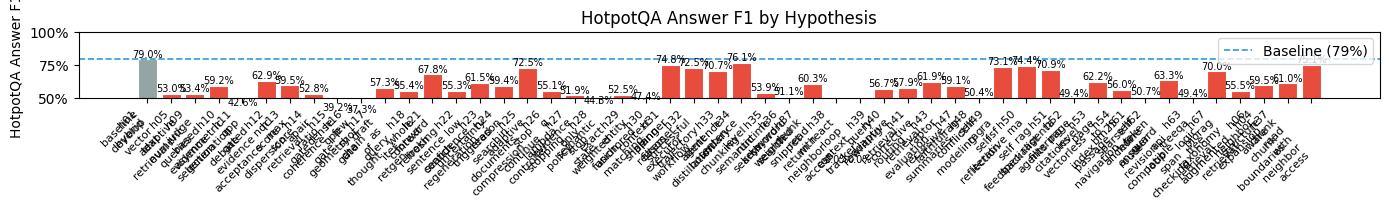

In [2]:
fig, ax = plt.subplots(figsize=(14, 5))
x = range(len(valid))
bars = ax.bar(x, valid["hotpot_answer_f1"], color=colors, edgecolor="white", linewidth=0.8)

# Baseline reference line
bl_row = valid.loc[valid["hypothesis_name"] == "baseline_develop"]
if len(bl_row) == 0:
    bl_row = valid.iloc[[0]]
baseline_f1 = bl_row["hotpot_answer_f1"].values[0]
ax.axhline(baseline_f1, color="#3498db", linestyle="--", linewidth=1.2, label=f"Baseline ({baseline_f1:.0%})")

ax.set_xticks(x)
ax.set_xticklabels(valid["label"], rotation=45, ha="right", fontsize=8)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_ylabel("HotpotQA Answer F1")
ax.set_title("HotpotQA Answer F1 by Hypothesis")
ax.set_ylim(0.5, 1.0)
ax.legend()

for i, v in enumerate(valid["hotpot_answer_f1"]):
    ax.text(i, v + 0.005, f"{v:.1%}", ha="center", va="bottom", fontsize=7)

plt.tight_layout()
plt.show()

## HotpotQA Metrics Comparison
Side-by-side Answer EM, Answer F1, and Joint F1 across all hypotheses.

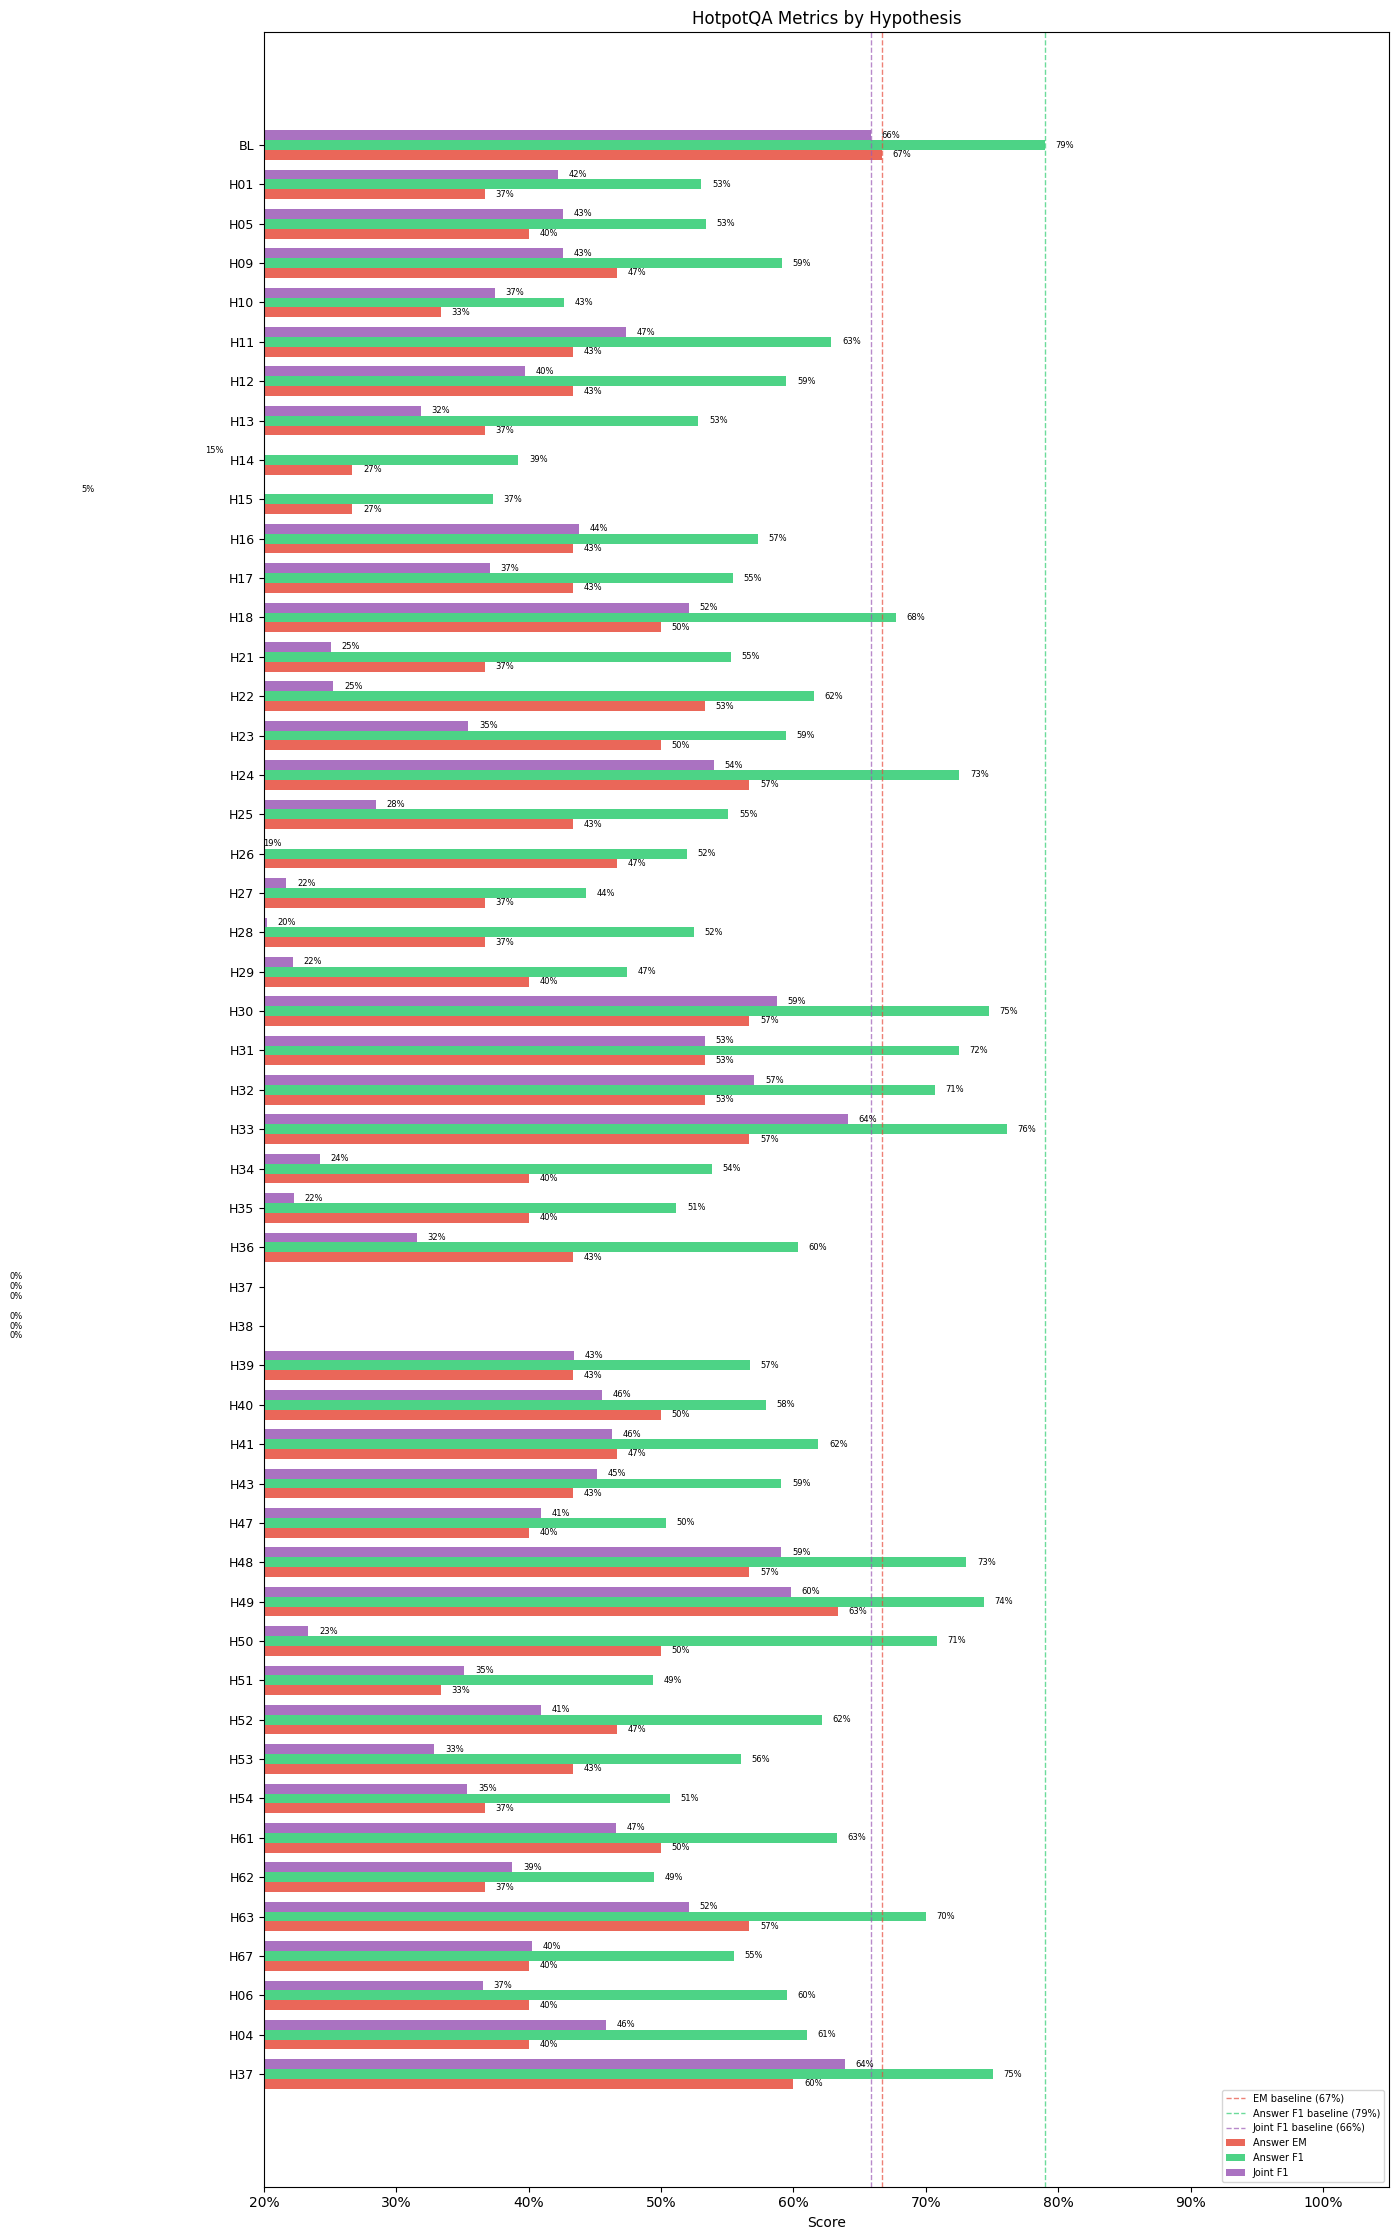

In [3]:
# Build short H## labels
def short_label(name):
    import re
    m = re.match(r"h(\d+)", name)
    if m:
        return f"H{m.group(1).zfill(2)}"
    if name == "baseline_develop":
        return "BL"
    if name == "baseline_reindexed_develop":
        return "BL-ri"
    return name[:8]

valid["short"] = valid["hypothesis_name"].apply(short_label)

# Baselines for dashed lines
bl_row = valid.loc[valid["hypothesis_name"] == "baseline_reindexed_develop"]
if len(bl_row) == 0:
    bl_row = valid.iloc[[0]]
hotpot_em_bl = bl_row["hotpot_answer_em"].values[0] if pd.notna(bl_row["hotpot_answer_em"].values[0]) else None
hotpot_af1_bl = bl_row["hotpot_answer_f1"].values[0] if pd.notna(bl_row["hotpot_answer_f1"].values[0]) else None
hotpot_jf1_bl = bl_row["hotpot_joint_f1"].values[0] if pd.notna(bl_row["hotpot_joint_f1"].values[0]) else None

fig, ax = plt.subplots(figsize=(14, max(5, len(valid) * 0.45)))
y = np.arange(len(valid))
width = 0.25

c_hotpot_em = "#e74c3c"
c_hotpot_af1 = "#2ecc71"
c_hotpot_jf1 = "#9b59b6"

ax.barh(y + width, valid["hotpot_answer_em"], width, label="Answer EM", color=c_hotpot_em, alpha=0.85)
ax.barh(y, valid["hotpot_answer_f1"], width, label="Answer F1", color=c_hotpot_af1, alpha=0.85)
ax.barh(y - width, valid["hotpot_joint_f1"], width, label="Joint F1", color=c_hotpot_jf1, alpha=0.85)

if hotpot_em_bl is not None:
    ax.axvline(hotpot_em_bl, color=c_hotpot_em, linestyle="--", linewidth=1, alpha=0.7, label=f"EM baseline ({hotpot_em_bl:.0%})")
if hotpot_af1_bl is not None:
    ax.axvline(hotpot_af1_bl, color=c_hotpot_af1, linestyle="--", linewidth=1, alpha=0.7, label=f"Answer F1 baseline ({hotpot_af1_bl:.0%})")
if hotpot_jf1_bl is not None:
    ax.axvline(hotpot_jf1_bl, color=c_hotpot_jf1, linestyle="--", linewidth=1, alpha=0.7, label=f"Joint F1 baseline ({hotpot_jf1_bl:.0%})")

for col, offset in [("hotpot_answer_em", 1), ("hotpot_answer_f1", 0), ("hotpot_joint_f1", -1)]:
    for i, v in enumerate(valid[col]):
        if pd.notna(v):
            ax.text(v + 0.008, i + offset * width, f"{v:.0%}", ha="left", va="center", fontsize=6)

ax.set_yticks(y)
ax.set_yticklabels(valid["short"], fontsize=9)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_xlabel("Score")
ax.set_title("HotpotQA Metrics by Hypothesis")
ax.set_xlim(0.2, 1.05)
ax.legend(loc="lower right", fontsize=7)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Cost vs Answer F1 Tradeoff
Bubble size = wall clock time. Ideal hypotheses are in the top-left (high F1, low cost).

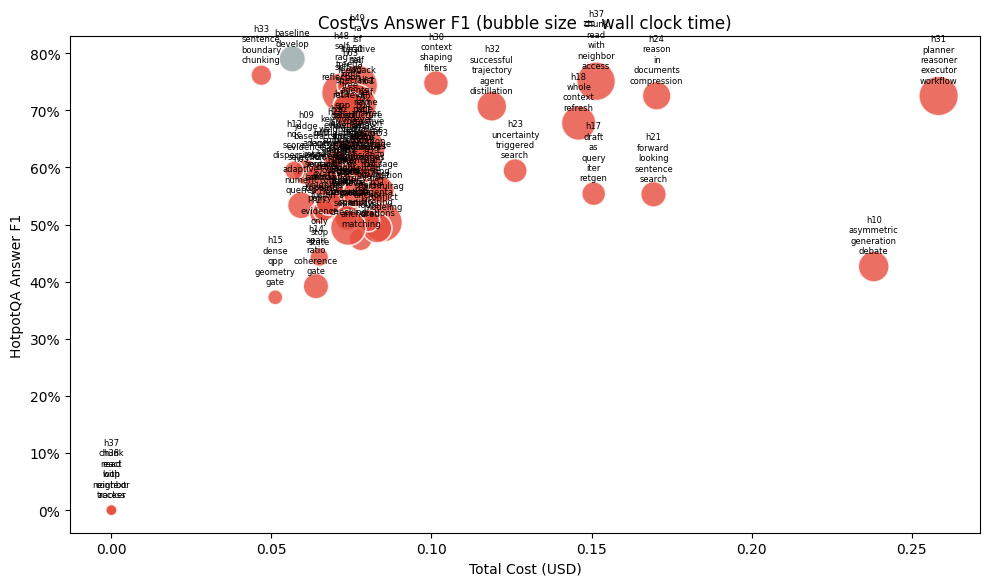

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))

sizes = valid["hotpot_wall_clock_s"] * 3  # scale for visibility
scatter = ax.scatter(
    valid["hotpot_total_cost_usd"], valid["hotpot_answer_f1"],
    s=sizes, c=colors, alpha=0.8, edgecolors="white", linewidth=1.2
)

for _, row in valid.iterrows():
    ax.annotate(
        row["hypothesis_name"].replace("_", "\n"),
        (row["hotpot_total_cost_usd"], row["hotpot_answer_f1"]),
        fontsize=6, ha="center", va="bottom",
        xytext=(0, 8), textcoords="offset points"
    )

ax.set_xlabel("Total Cost (USD)")
ax.set_ylabel("HotpotQA Answer F1")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title("Cost vs Answer F1 (bubble size = wall clock time)")
plt.tight_layout()
plt.show()

## Cost & Wall Clock Time

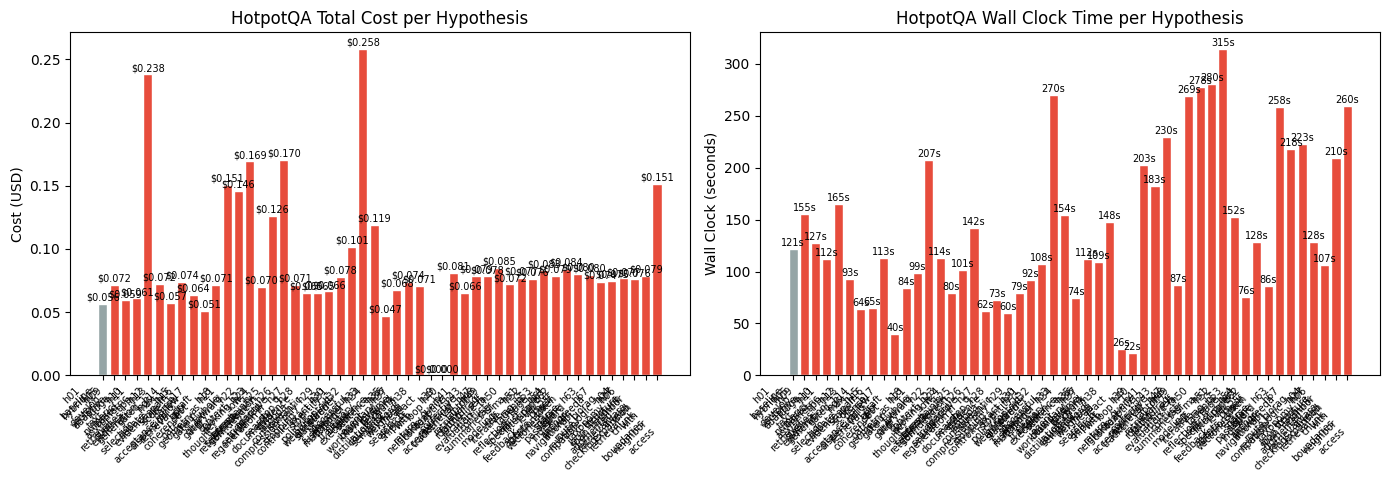

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cost comparison
ax = axes[0]
x = range(len(valid))
ax.bar(x, valid["hotpot_total_cost_usd"], color=colors, edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels(valid["label"], rotation=45, ha="right", fontsize=7)
ax.set_ylabel("Cost (USD)")
ax.set_title("HotpotQA Total Cost per Hypothesis")
for i, v in enumerate(valid["hotpot_total_cost_usd"]):
    ax.text(i, v + 0.001, f"${v:.3f}", ha="center", va="bottom", fontsize=7)

# Wall clock time
ax = axes[1]
ax.bar(x, valid["hotpot_wall_clock_s"], color=colors, edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels(valid["label"], rotation=45, ha="right", fontsize=7)
ax.set_ylabel("Wall Clock (seconds)")
ax.set_title("HotpotQA Wall Clock Time per Hypothesis")
for i, v in enumerate(valid["hotpot_wall_clock_s"]):
    ax.text(i, v + 1, f"{v:.0f}s", ha="center", va="bottom", fontsize=7)

plt.tight_layout()
plt.show()

## Token Composition (Input vs Cached vs Output)

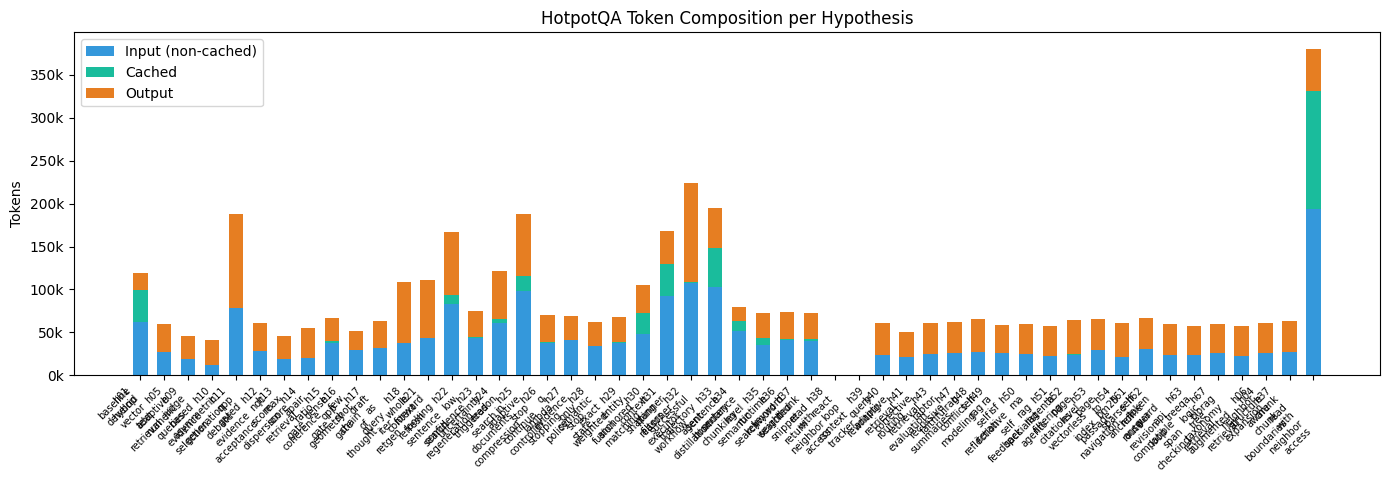

In [6]:
fig, ax = plt.subplots(figsize=(14, 5))

x = np.arange(len(valid))
width = 0.6

# Stacked bar: input (non-cached), cached, output
non_cached_input = valid["hotpot_input_tokens"] - valid["hotpot_cached_tokens"]
ax.bar(x, non_cached_input, width, label="Input (non-cached)", color="#3498db")
ax.bar(x, valid["hotpot_cached_tokens"], width, bottom=non_cached_input, label="Cached", color="#1abc9c")
ax.bar(x, valid["hotpot_output_tokens"], width, bottom=valid["hotpot_input_tokens"], label="Output", color="#e67e22")

ax.set_xticks(x)
ax.set_xticklabels(valid["label"], rotation=45, ha="right", fontsize=7)
ax.set_ylabel("Tokens")
ax.set_title("HotpotQA Token Composition per Hypothesis")
ax.legend()
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v/1000:.0f}k"))

plt.tight_layout()
plt.show()

## Summary: Promoted vs Rejected Hypotheses

In [7]:
summary = valid.groupby("decision").agg(
    count=("hypothesis_name", "count"),
    avg_hotpot_answer_f1=("hotpot_answer_f1", "mean"),
    avg_hotpot_joint_f1=("hotpot_joint_f1", "mean"),
    avg_hotpot_cost=("hotpot_total_cost_usd", "mean"),
    avg_wall_clock_s=("hotpot_wall_clock_s", "mean"),
).round(4)

print(summary.to_string())
print(f"\nPromotion rate: {(valid['decision'] == 'promoted').sum()}/{len(valid)} = {(valid['decision'] == 'promoted').mean():.0%}")

          count  avg_hotpot_answer_f1  avg_hotpot_joint_f1  avg_hotpot_cost  avg_wall_clock_s
decision                                                                                     
rejected     49                0.5625               0.3737           0.0875          139.6224

Promotion rate: 0/50 = 0%
